<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/ReinforcementLearningAndDecisionMaking/ReinforcementLearningAndDecisionMaking/Slippage_Aware_RL_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

In [2]:
# --- CONFIG ---
TICKER = "ETH-USD" # Ethereum has high slippage during crashes
START = "2019-01-01"
END = "2024-01-01"
WINDOW_SIZE = 30
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# --- MICROSTRUCTURE DATA ---
def get_data(ticker):
    print(f"⬇️ Downloading Market Depth Proxy for {ticker}...")
    df = yf.download(ticker, start=START, end=END, progress=False)
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)

    df.ffill(inplace=True)
    df.bfill(inplace=True)

    # 1. Log Returns
    df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))

    # 2. ATR (Volatility / Spread Proxy)
    # High ATR = Wide Spreads = High Slippage
    high_low = df['High'] - df['Low']
    high_close = np.abs(df['High'] - df['Close'].shift())
    low_close = np.abs(df['Low'] - df['Close'].shift())
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df['ATR'] = tr.rolling(14).mean()
    df['ATR_Pct'] = df['ATR'] / df['Close'] # Normalized volatility

    # 3. RVOL (Relative Volume / Liquidity Proxy)
    # Low Volume = Thin Orderbook = High Slippage
    df['Vol_MA'] = df['Volume'].rolling(20).mean()
    df['RVOL'] = df['Volume'] / (df['Vol_MA'] + 1e-7)

    # 4. RSI (Momentum)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / (loss + 1e-7)
    df['RSI'] = 100 - (100 / (1 + rs))

    df.dropna(inplace=True)
    return df

df = get_data(TICKER)
print(f"✅ Data Ready: {len(df)} candles.")

⬇️ Downloading Market Depth Proxy for ETH-USD...


/tmp/ipython-input-315914716.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START, end=END, progress=False)


✅ Data Ready: 1807 candles.


In [4]:
class SlippageEnv(gym.Env):
    def __init__(self, df, use_slippage=True):
        super(SlippageEnv, self).__init__()
        self.df = df
        self.use_slippage = use_slippage

        # Obs: [Log_Ret, ATR_Pct, RVOL, RSI, Pos_Flag]
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(WINDOW_SIZE, 5), dtype=np.float32)
        self.action_space = spaces.Discrete(3)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = WINDOW_SIZE
        self.balance = 10000.0
        self.shares = 0.0
        self.net_worth = 10000.0
        self.prev_net_worth = 10000.0
        self.total_slippage_cost = 0.0 # Track how much we lost to friction
        return self._get_obs(), {}

    def _get_obs(self):
        frame = self.df.iloc[self.current_step-WINDOW_SIZE : self.current_step]
        obs = frame[['Log_Ret', 'ATR_Pct', 'RVOL', 'RSI']].values
        pos_flag = np.full((WINDOW_SIZE, 1), 1.0 if self.shares > 0 else 0.0)
        return np.hstack((obs, pos_flag)).astype(np.float32)

    def _calculate_slippage(self):
        if not self.use_slippage: return 0.0

        # DYNAMIC SLIPPAGE MODEL
        # Base Slippage (Spread) = 0.1%
        # Volatility Penalty = 0.5 * ATR% (If ATR is 5%, adds 2.5% slippage!)
        # Liquidity Penalty = If RVOL < 0.5 (Low Vol), double the penalty.

        row = self.df.iloc[self.current_step]
        atr_pct = float(row['ATR_Pct'])
        rvol = float(row['RVOL'])

        slip = 0.001 + (0.5 * atr_pct)

        if rvol < 0.5: # Thin market
            slip *= 1.5

        return slip

    def step(self, action):
        price = float(self.df.iloc[self.current_step]['Close'])
        slippage_pct = self._calculate_slippage()

        # Execute Trade
        if action == 1 and self.balance > 0: # Buy
            exec_price = price * (1 + slippage_pct) # Buy higher
            self.shares = self.balance / exec_price
            self.total_slippage_cost += self.balance * slippage_pct
            self.balance = 0

        elif action == 2 and self.shares > 0: # Sell
            exec_price = price * (1 - slippage_pct) # Sell lower
            revenue = self.shares * exec_price
            self.total_slippage_cost += revenue * slippage_pct
            self.balance = revenue
            self.shares = 0

        self.current_step += 1

        # Update Worth
        next_price = float(self.df.iloc[self.current_step]['Close'])
        self.net_worth = self.balance + (self.shares * next_price)

        # Reward = Log Return of Portfolio
        step_ret = (self.net_worth - self.prev_net_worth) / self.prev_net_worth
        self.prev_net_worth = self.net_worth

        reward = step_ret * 100

        terminated = self.net_worth < 2000 # Bust
        truncated = self.current_step >= len(self.df) - 5

        return self._get_obs(), reward, terminated, truncated, {
            'net_worth': self.net_worth,
            'slippage_cost': self.total_slippage_cost
        }

In [6]:
class PPOAgent:
    def __init__(self, input_dim, action_dim):
        self.gamma = 0.99
        self.clip_ratio = 0.2
        self.K_epochs = 3

        # Initialize networks (Force them to float32 explicitly)
        self.actor = nn.Sequential(
            nn.Linear(input_dim, 128), nn.Tanh(),
            nn.Linear(128, action_dim), nn.Softmax(dim=-1)
        ).float().to(DEVICE)

        self.critic = nn.Sequential(
            nn.Linear(input_dim, 128), nn.Tanh(),
            nn.Linear(128, 1)
        ).float().to(DEVICE)

        self.optimizer = optim.Adam(list(self.actor.parameters()) + list(self.critic.parameters()), lr=0.0003)
        self.reset_memory()

    def reset_memory(self):
        self.states, self.actions, self.logprobs, self.rewards, self.dones = [], [], [], [], []

    def select_action(self, state):
        # Force input to float32
        state = torch.FloatTensor(state).float().flatten().unsqueeze(0).to(DEVICE)
        dist = Categorical(self.actor(state))
        action = dist.sample()
        return action.item(), dist.log_prob(action).item()

    def record(self, s, a, lp, r, d):
        # Force state to float32 immediately upon recording
        self.states.append(torch.tensor(s, dtype=torch.float32).flatten())
        self.actions.append(torch.tensor(a))
        self.logprobs.append(torch.tensor(lp))
        self.rewards.append(r)
        self.dones.append(d)

    def learn(self):
        if not self.states: return

        # 1. Convert lists to Tensors (STRICTLY FLOAT32)
        # Note: torch.stack expects tensors of same type
        states = torch.stack(self.states).to(DEVICE)
        actions = torch.stack(self.actions).to(DEVICE)
        old_logprobs = torch.stack(self.logprobs).to(DEVICE)

        # 2. Calculate Returns (Monte Carlo)
        returns = []
        discounted_sum = 0
        for reward, is_terminal in zip(reversed(self.rewards), reversed(self.dones)):
            if is_terminal: discounted_sum = 0
            discounted_sum = reward + (0.99 * discounted_sum)
            returns.insert(0, discounted_sum)

        # --- CRITICAL FIX: Force Returns to Float32 ---
        returns = torch.tensor(returns, dtype=torch.float32).to(DEVICE)

        # Normalize Returns (Safety)
        if returns.std() > 1e-5:
            returns = (returns - returns.mean()) / (returns.std() + 1e-7)
        else:
            returns = returns - returns.mean()

        # 3. Update Loop
        for _ in range(self.K_epochs):
            # Evaluate (Actor & Critic are float32, so inputs must be too)
            probs = self.actor(states)
            dist = Categorical(probs)
            new_logprobs = dist.log_prob(actions)
            entropy = dist.entropy().mean()

            # Critic Value
            state_values = self.critic(states).squeeze()

            # Ratios & Advantages
            ratio = torch.exp(new_logprobs - old_logprobs)

            # Ensure subtraction is float32 - float32
            advantages = returns - state_values.detach()

            # Loss Calculation
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1-self.clip_ratio, 1+self.clip_ratio) * advantages

            loss = -torch.min(surr1, surr2) + 0.5 * nn.MSELoss()(state_values, returns) - 0.01 * entropy

            self.optimizer.zero_grad()
            loss.mean().backward()

            # Gradient Clipping (Prevents explosion)
            torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
            torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)

            self.optimizer.step()

        self.reset_memory()

In [7]:
# Re-using the Robust PPO Agent (Ensure Block 4 from previous conversation is defined)
# If not defined in current session, please re-run the "Strictly Typed PPO Agent" block.

def train_agent(name, use_slippage):
    print(f"\n🥋 Training {name} (Slippage In Training: {use_slippage})...")

    # Initialize Env
    train_env = SlippageEnv(df, use_slippage=use_slippage)

    # Get Shape
    obs_shape = train_env.observation_space.shape
    input_dim = obs_shape[0] * obs_shape[1]

    agent = PPOAgent(input_dim=input_dim, action_dim=3)

    # Train for 40 Episodes
    for ep in range(40):
        s, _ = train_env.reset()
        done = False
        while not done:
            s = s.astype(np.float32)
            a, lp = agent.select_action(s)
            ns, r, term, trunc, _ = train_env.step(a)
            done = term or trunc
            agent.record(s, a, lp, r, done)
            s = ns

            if train_env.current_step % 2048 == 0:
                agent.learn()

    return agent

# 1. Train Naive Agent (Thinks slippage is 0)
naive_agent = train_agent("Naive Agent", use_slippage=False)

# 2. Train Aware Agent (Experiences slippage)
aware_agent = train_agent("Pro Agent", use_slippage=True)


🥋 Training Naive Agent (Slippage In Training: False)...

🥋 Training Pro Agent (Slippage In Training: True)...


In [8]:
print(f"\n⚔️ STARTING THE DUEL (Environment: REAL SLIPPAGE)...")

agents = {"Naive Agent": naive_agent, "Pro Agent": aware_agent}
results = {}
costs = {}

for name, agent in agents.items():
    # TEST ENVIRONMENT: ALWAYS HAS SLIPPAGE ON
    test_env = SlippageEnv(df, use_slippage=True)

    s, _ = test_env.reset()
    done = False
    curve = []

    while not done:
        with torch.no_grad():
            s_val = s.astype(np.float32)
            s_t = torch.FloatTensor(s_val).flatten().unsqueeze(0).to(DEVICE)
            action = torch.argmax(agent.actor(s_t)).item()

        s, _, term, trunc, info = test_env.step(action)
        done = term or trunc
        curve.append(info['net_worth'])

    results[name] = curve
    costs[name] = info['slippage_cost']
    print(f"{name} Final Worth: ${info['net_worth']:.0f} | Lost to Slippage: ${info['slippage_cost']:.0f}")


⚔️ STARTING THE DUEL (Environment: REAL SLIPPAGE)...
Naive Agent Final Worth: $14182 | Lost to Slippage: $39424
Pro Agent Final Worth: $10000 | Lost to Slippage: $0


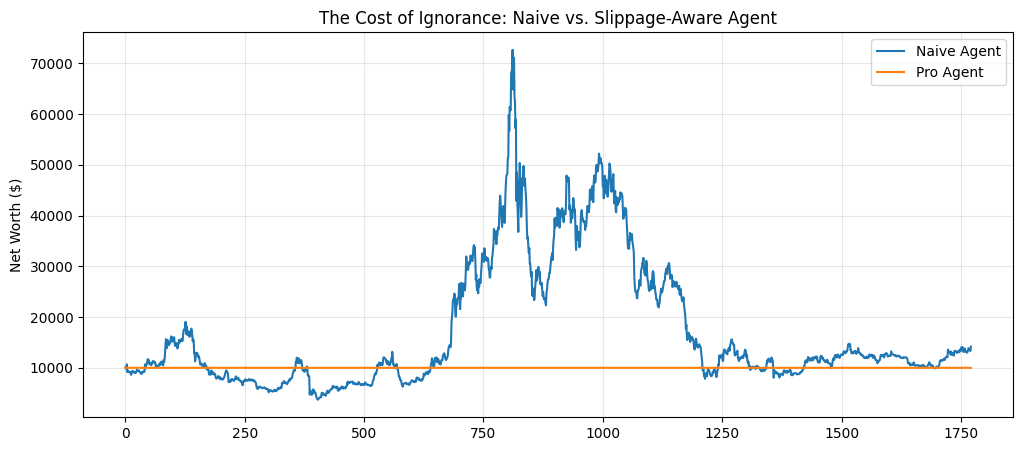

In [9]:
# --- PLOT 1: EQUITY CURVES ---
plt.figure(figsize=(12, 5))
for name, curve in results.items():
    plt.plot(curve, label=name)
plt.title("The Cost of Ignorance: Naive vs. Slippage-Aware Agent")
plt.ylabel("Net Worth ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

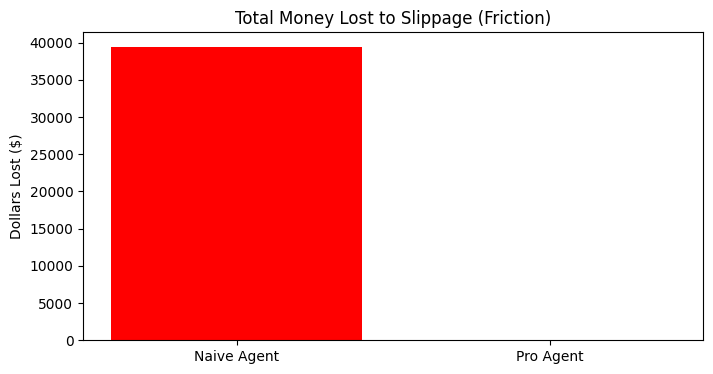

In [10]:
# --- PLOT 2: HIDDEN COSTS ---
plt.figure(figsize=(8, 4))
names = list(costs.keys())
values = list(costs.values())
plt.bar(names, values, color=['red', 'green'])
plt.title("Total Money Lost to Slippage (Friction)")
plt.ylabel("Dollars Lost ($)")
plt.show()